# Notebook 02 — Tarea 2: Regresión
**Objetivo:** predecir `nota_media_2sem` (calificación media del 2.º semestre).

**Modelos:** Ridge · Lasso · Árbol de Decisión · Random Forest · Gradient Boosting

---
### Justificación de exclusión por Data Leakage

Las siguientes variables **no pueden usarse como predictores**:

| Variable excluida | Razón |
|---|---|
| `asignaturas_2sem_matriculadas` | Describe el 2.º semestre simultáneamente al target |
| `asignaturas_2sem_evaluadas` | Ídem |
| `asignaturas_2sem_aprobadas` | Correlación casi perfecta con la nota |
| `asignaturas_2sem_sin_evaluacion` | Ídem |
| `asignaturas_2sem_convalidadas` | Ídem |
| `objetivo` | Situación final determinada parcialmente por el 2.º semestre |

Incluirlas haría trivial la predicción e invalidaría el modelo para uso real.

## 0. Imports y configuración

In [1]:
import sys, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, KFold, cross_validate
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import Ridge, Lasso
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection       import permutation_importance

from utils import (load_data, set_plot_style, encode_binary_cols,
                   regression_metrics, plot_feature_importance,
                   RANDOM_STATE, TARGET_REG, LEAKAGE_COLS_REGRESION)

os.makedirs("../outputs", exist_ok=True)
set_plot_style()

## 1. Carga y selección de variables

In [2]:
df = load_data("../rendimiento_estudiantes.csv")
df = encode_binary_cols(df)

EXCLUIR     = LEAKAGE_COLS_REGRESION + ["objetivo"]
feature_cols = [c for c in df.columns if c not in EXCLUIR]
print(f"Predictores disponibles ({len(feature_cols)}):")
print(feature_cols)

Predictores disponibles (30):
['estado_civil', 'modo_solicitud', 'orden_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'nota_cualificacion_previa', 'nacionalidad', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'nota_admision', 'desplazado', 'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'genero', 'becado', 'edad_al_matricularse', 'internacional', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']


In [3]:
# Excluir filas con nota_media_2sem == 0
# (estudiantes que no llegaron a ser evaluados en 2.º semestre)
df_reg = df[df[TARGET_REG] > 0].copy()
print(f"Filas con nota > 0: {len(df_reg)} (eliminadas: {len(df) - len(df_reg)})")

X = df_reg[feature_cols]
y = df_reg[TARGET_REG]

Filas con nota > 0: 3554 (eliminadas: 870)


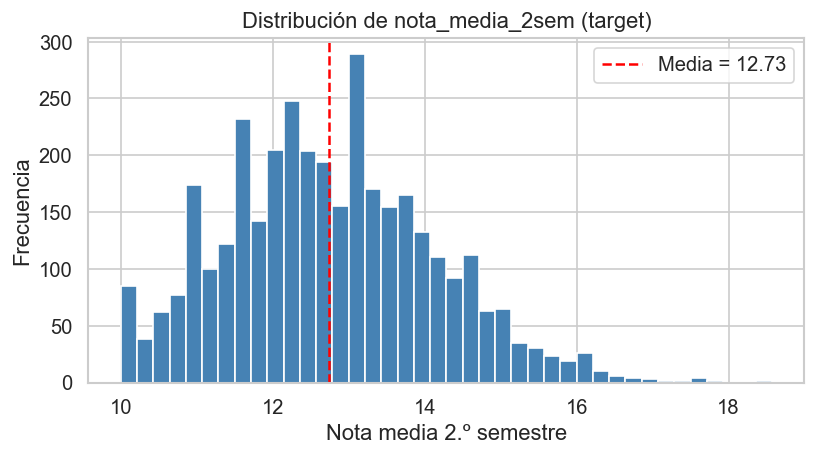

Media: 12.73 | Std: 1.38 | Min: 10.00 | Max: 18.57


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y, bins=40, color="steelblue", edgecolor="white")
ax.axvline(y.mean(), color="red", linestyle="--", label=f"Media = {y.mean():.2f}")
ax.set_title("Distribución de nota_media_2sem (target)")
ax.set_xlabel("Nota media 2.º semestre")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02_distribucion_target.png", bbox_inches="tight")
plt.show()
print(f"Media: {y.mean():.2f} | Std: {y.std():.2f} | Min: {y.min():.2f} | Max: {y.max():.2f}")

## 2. Preprocesado

In [5]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

Train: 2843 | Test: 711


## 3. Definición de modelos

In [6]:
modelos = {
    "Ridge": Pipeline([
        ("prep", preprocessor),
        ("reg",  Ridge(alpha=1.0)),
    ]),
    "Lasso": Pipeline([
        ("prep", preprocessor),
        ("reg",  Lasso(alpha=0.01, max_iter=5000)),
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("reg",  DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("reg",  RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("reg",  GradientBoostingRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            random_state=RANDOM_STATE,
        )),
    ]),
}

## 4. Validación cruzada 5-fold

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = {}
for nombre, modelo in modelos.items():
    print(f"Evaluando {nombre}...", end=" ", flush=True)
    scores = cross_validate(
        modelo, X_train, y_train, cv=cv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        n_jobs=-1,
    )
    resultados_cv[nombre] = {
        "RMSE":  -scores["test_neg_root_mean_squared_error"].mean(),
        "MAE":   -scores["test_neg_mean_absolute_error"].mean(),
        "R2":     scores["test_r2"].mean(),
        "RMSE std": scores["test_neg_root_mean_squared_error"].std(),
    }
    r = resultados_cv[nombre]
    print(f"RMSE = {r['RMSE']:.4f} ± {r['RMSE std']:.4f} | R² = {r['R2']:.4f}")

df_cv = pd.DataFrame(resultados_cv).T
print()
print(df_cv.round(4).to_string())
df_cv.to_csv("../outputs/02_resultados_cv.csv")

Evaluando Ridge... RMSE = 1.0987 ± 0.0316 | R² = 0.3663
Evaluando Lasso... RMSE = 1.0835 ± 0.0334 | R² = 0.3837
Evaluando Decision Tree... RMSE = 1.0442 ± 0.0290 | R² = 0.4274
Evaluando Random Forest... RMSE = 0.9659 ± 0.0179 | R² = 0.5101
Evaluando Gradient Boosting... RMSE = 0.9464 ± 0.0148 | R² = 0.5296

                     RMSE     MAE      R2  RMSE std
Ridge              1.0987  0.8471  0.3663    0.0316
Lasso              1.0835  0.8371  0.3837    0.0334
Decision Tree      1.0442  0.7924  0.4274    0.0290
Random Forest      0.9659  0.7312  0.5101    0.0179
Gradient Boosting  0.9464  0.7171  0.5296    0.0148


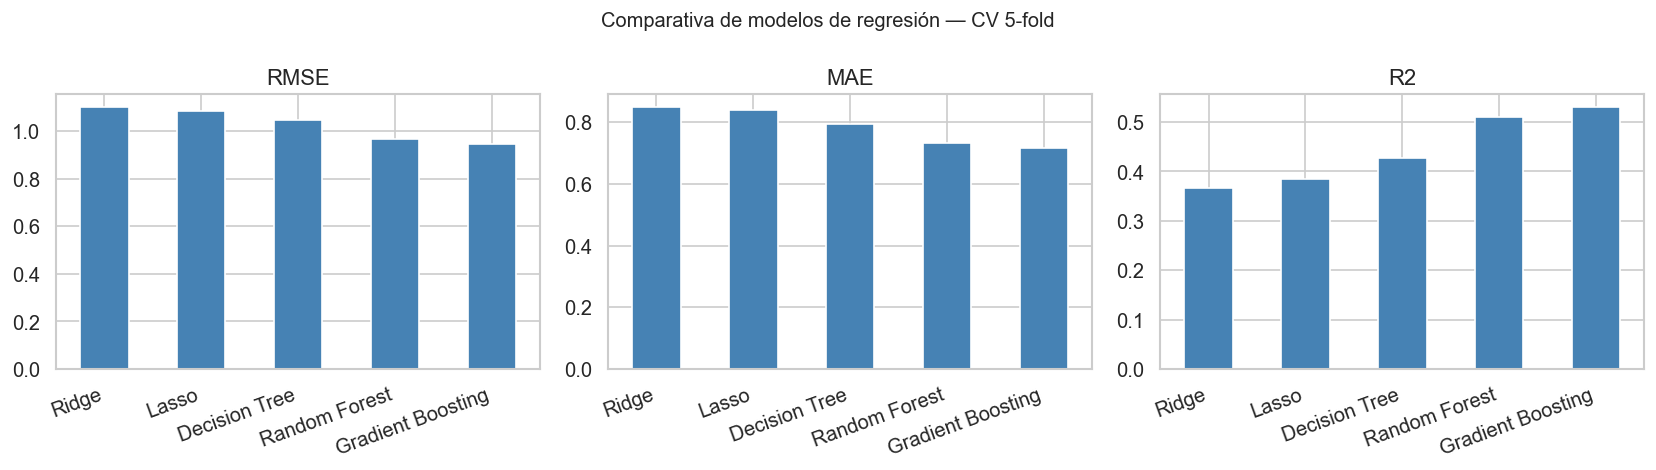

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    df_cv[metric].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(metric)
    ax.set_xticklabels(df_cv.index, rotation=20, ha="right")
plt.suptitle("Comparativa de modelos de regresión — CV 5-fold", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/02_comparativa_modelos.png", bbox_inches="tight")
plt.show()

## 5. Evaluación en test y análisis de residuos

In [9]:
resultados_test = {}
preds_test      = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    preds_test[nombre] = y_pred
    resultados_test[nombre] = regression_metrics(y_test, y_pred)

df_test = pd.DataFrame(resultados_test).T
print("Resultados en TEST:")
print(df_test.round(4).to_string())
df_test.to_csv("../outputs/02_resultados_test.csv")

mejor_nombre = df_cv["RMSE"].idxmin()
y_pred_best  = preds_test[mejor_nombre]
print(f"\nMejor modelo: {mejor_nombre}")

Resultados en TEST:
                     RMSE     MAE      R2
Ridge              1.0549  0.8286  0.3994
Lasso              1.0688  0.8382  0.3834
Decision Tree      0.9984  0.7558  0.4619
Random Forest      0.9310  0.7169  0.5321
Gradient Boosting  0.9301  0.7070  0.5330

Mejor modelo: Gradient Boosting


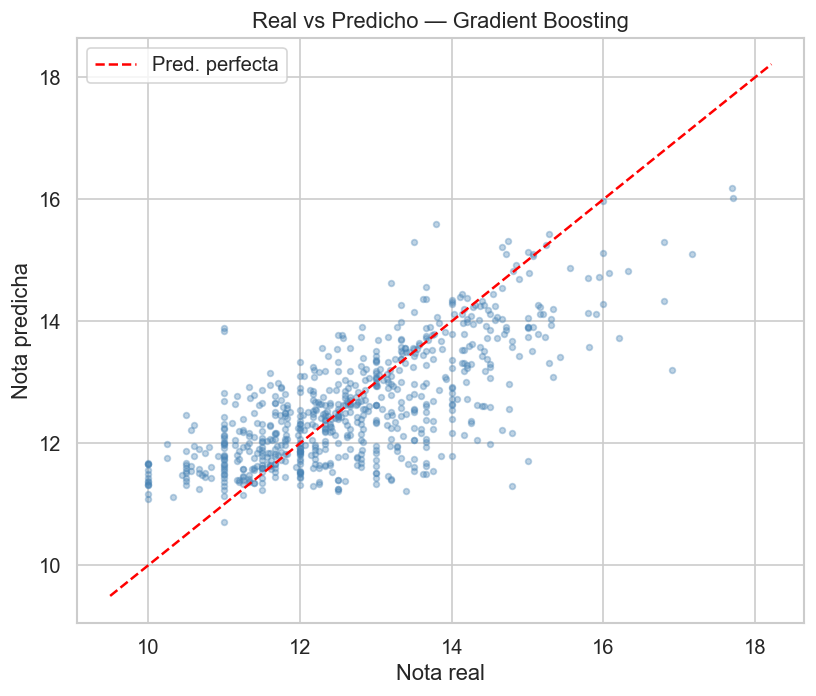

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.35, s=12, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()) - 0.5,
        max(y_test.max(), y_pred_best.max()) + 0.5]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Pred. perfecta")
ax.set_xlabel("Nota real")
ax.set_ylabel("Nota predicha")
ax.set_title(f"Real vs Predicho — {mejor_nombre}")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02_real_vs_predicho.png", bbox_inches="tight")
plt.show()

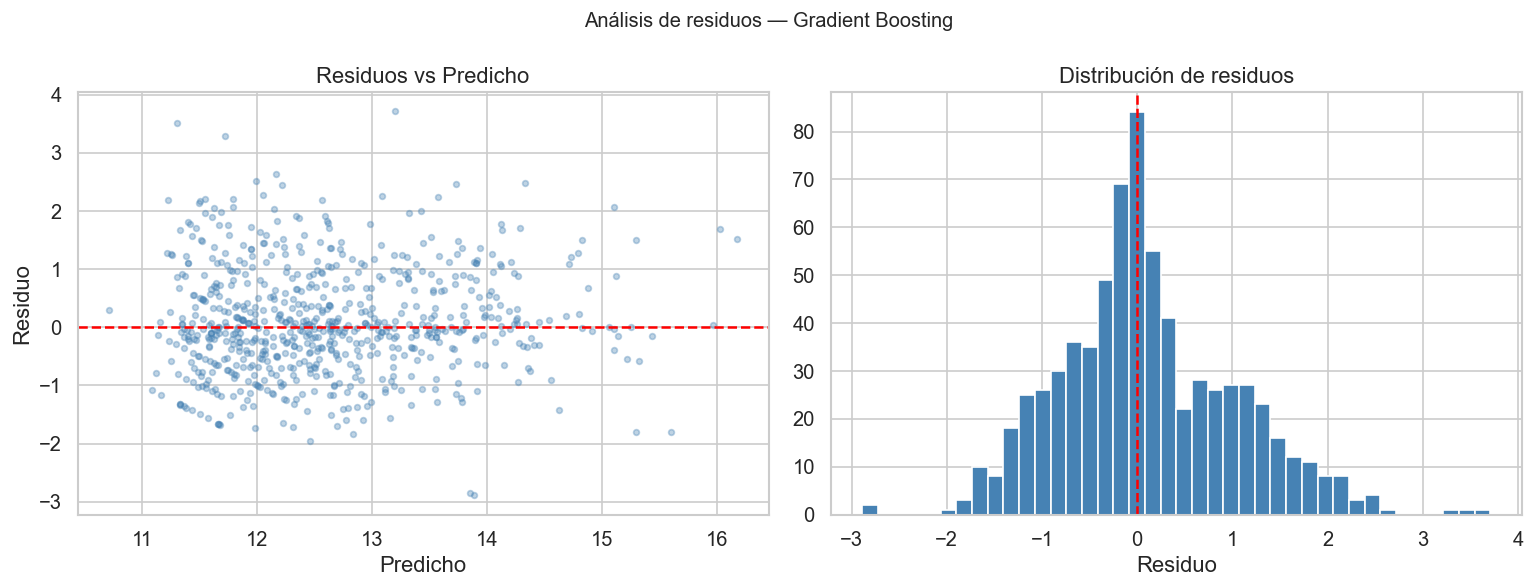

Residuos — media: 0.1010 | std: 0.9246


In [11]:
residuos = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_best, residuos, alpha=0.35, s=12, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Residuo")
axes[0].set_title("Residuos vs Predicho")

axes[1].hist(residuos, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")

plt.suptitle(f"Análisis de residuos — {mejor_nombre}", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/02_residuos.png", bbox_inches="tight")
plt.show()
print(f"Residuos — media: {residuos.mean():.4f} | std: {residuos.std():.4f}")

## 6. Importancia de variables — Random Forest (MDI)

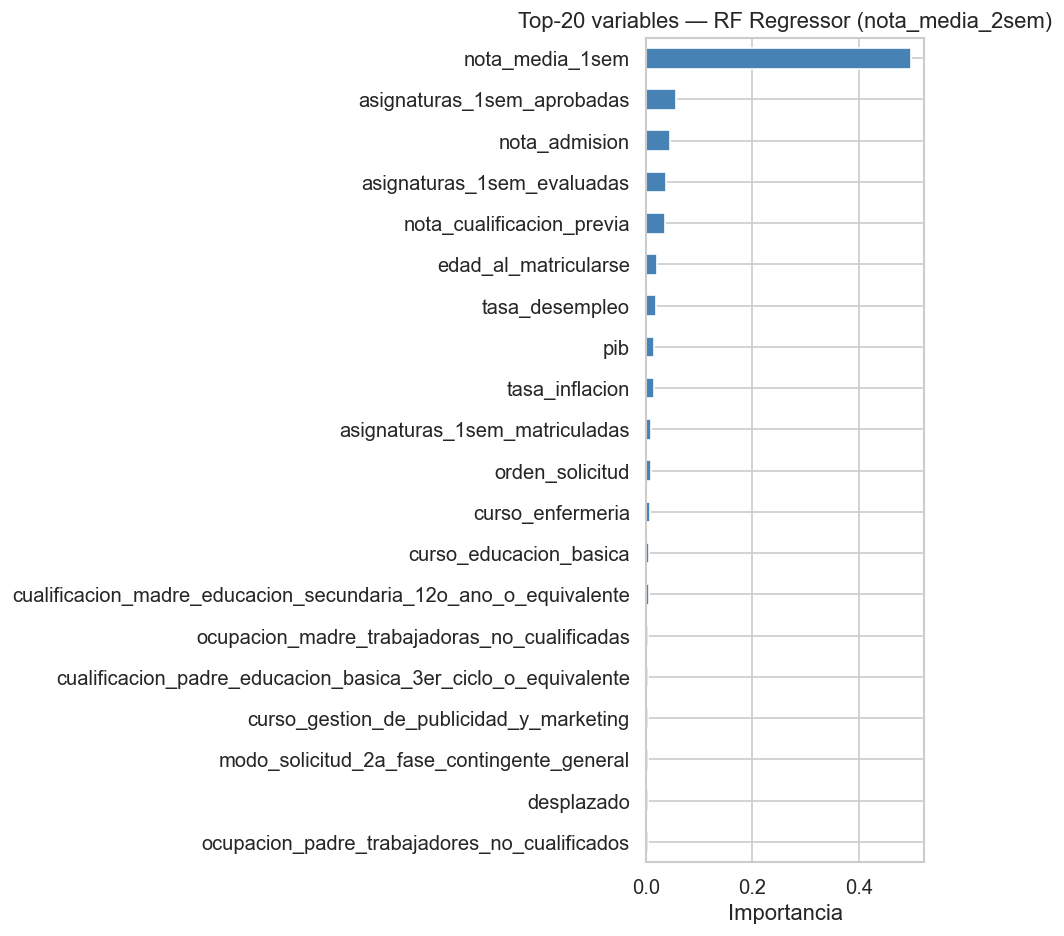

In [12]:
rf_pipe   = modelos["Random Forest"]
rf_reg    = rf_pipe.named_steps["reg"]
ohe       = rf_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feat  = ohe.get_feature_names_out(cat_cols).tolist()
feat_names = num_cols + cat_feat

imp = pd.Series(rf_reg.feature_importances_, index=feat_names)
fig, ax = plt.subplots(figsize=(8, 8))
plot_feature_importance(imp, top_n=20,
                        title="Top-20 variables — RF Regressor (nota_media_2sem)", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/02_feature_importance_rf.png", bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).to_csv(
    "../outputs/02_feature_importances.csv", header=["importance"])

## 7. Permutation Importance

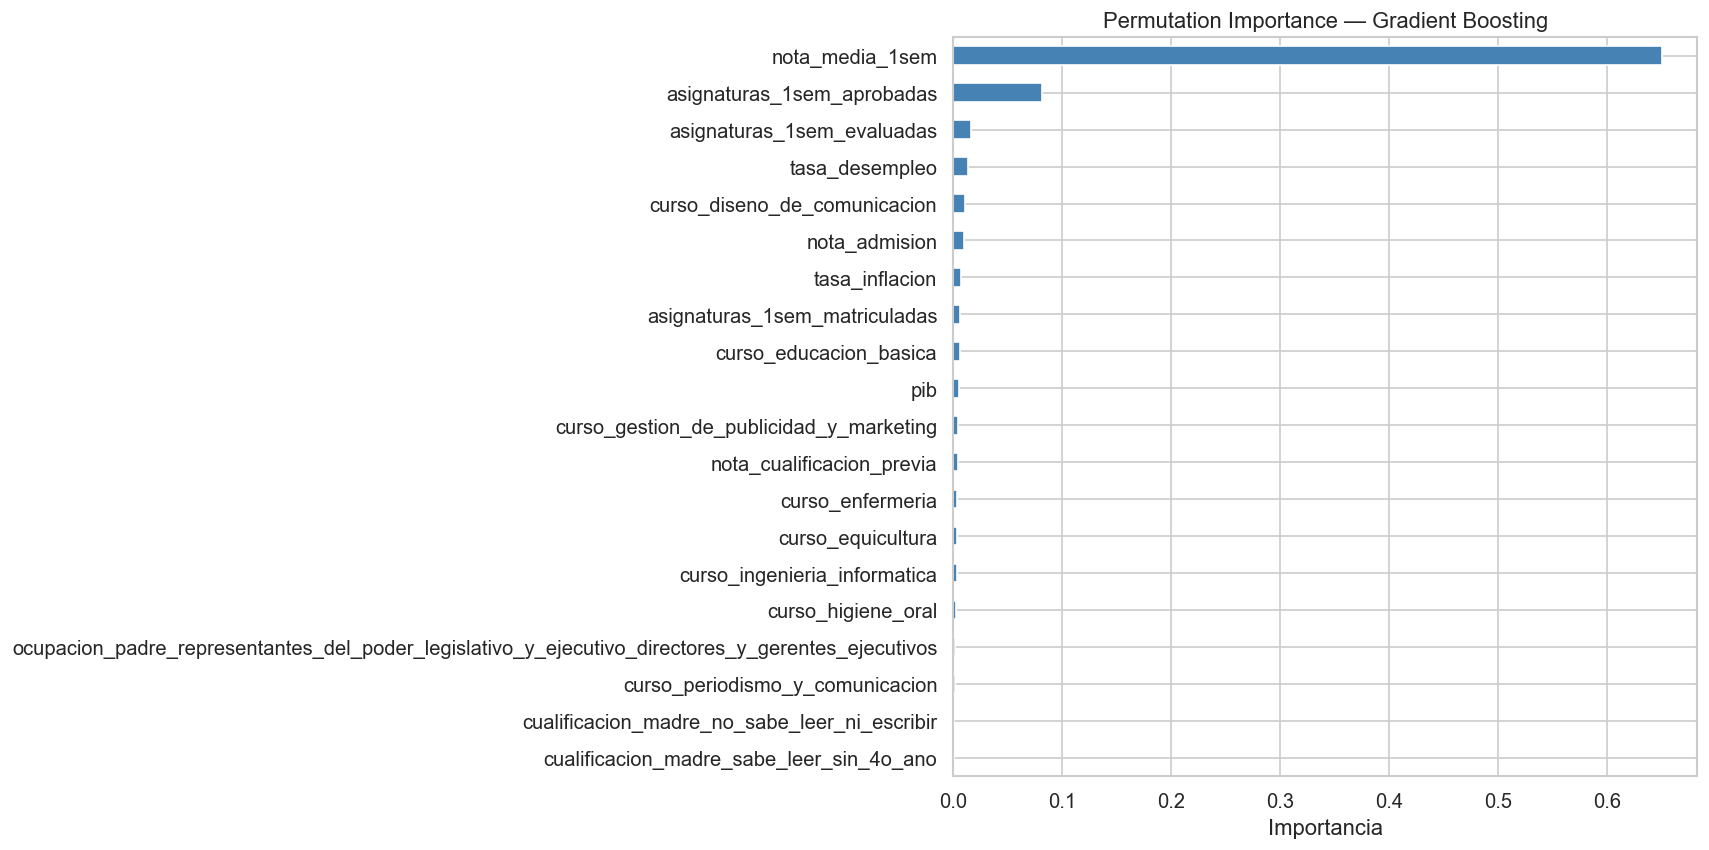

In [13]:
best_pipe   = modelos[mejor_nombre]
X_test_prep = best_pipe.named_steps["prep"].transform(X_test)

perm = permutation_importance(
    best_pipe.named_steps["reg"],
    X_test_prep, y_test,
    scoring="r2", n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1,
)
perm_s = pd.Series(perm.importances_mean, index=feat_names)

fig, ax = plt.subplots(figsize=(8, 8))
plot_feature_importance(perm_s, top_n=20,
                        title=f"Permutation Importance — {mejor_nombre}", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/02_permutation_importance.png", bbox_inches="tight")
plt.show()

## 8. Comparativa de selección de variables

Contrastamos usar **solo el perfil de entrada** (sin información semestral) frente a añadir las **variables del 1.er semestre**. Esto permite cuantificar cuánto aporta el rendimiento inicial para predecir el 2.º semestre.

Solo perfil entrada: RMSE=1.2177 | R²=0.1996
Perfil + 1er semestre: RMSE=0.9310 | R²=0.5321


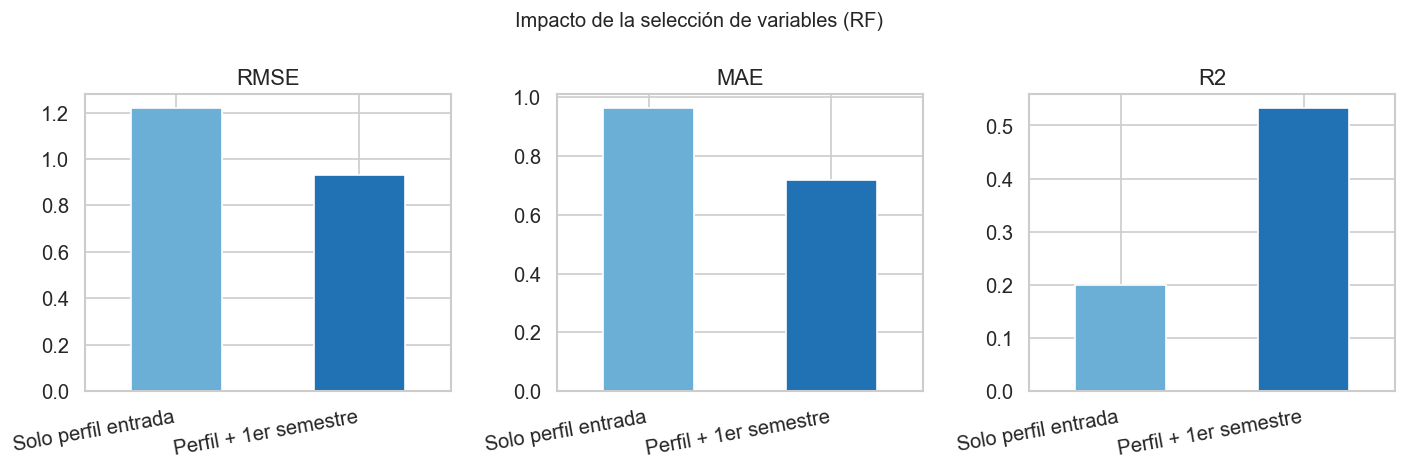

In [14]:
cols_perfil   = [c for c in feature_cols if "1sem" not in c]
cols_completo = feature_cols

resultados_sel = {}
for etiqueta, cols in [("Solo perfil entrada", cols_perfil),
                        ("Perfil + 1er semestre", cols_completo)]:
    Xs = df_reg[cols]
    cs = Xs.select_dtypes(include="object").columns.tolist()
    ns = Xs.select_dtypes(exclude="object").columns.tolist()
    ps = ColumnTransformer([
        ("num", StandardScaler(), ns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cs),
    ])
    pipe_s = Pipeline([
        ("prep", ps),
        ("reg",  RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, random_state=RANDOM_STATE)
    pipe_s.fit(Xtr, ytr)
    m = regression_metrics(yte, pipe_s.predict(Xte))
    resultados_sel[etiqueta] = m
    print(f"{etiqueta}: RMSE={m['RMSE']:.4f} | R²={m['R2']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
df_sel = pd.DataFrame(resultados_sel).T
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    df_sel[metric].plot(kind="bar", ax=ax,
                        color=["#6baed6", "#2171b5"], edgecolor="white", width=0.5)
    ax.set_title(metric)
    ax.set_xticklabels(df_sel.index, rotation=10, ha="right")
plt.suptitle("Impacto de la selección de variables (RF)", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/02_comparativa_seleccion_vars.png", bbox_inches="tight")
plt.show()

## 9. Predicciones finales

In [15]:
pred_df = pd.DataFrame({
    "indice_test":   X_test.index,
    "nota_real":     y_test.values,
    "nota_predicha": y_pred_best.round(3),
    "residuo":       residuos.round(3),
})
pred_df.to_csv("../outputs/02_predicciones_regresion.csv", index=False)
print("Predicciones guardadas en outputs/02_predicciones_regresion.csv")

Predicciones guardadas en outputs/02_predicciones_regresion.csv


## 10. Conclusiones

- Sin leakage, el mejor modelo obtiene **R² ≈ 0.65–0.75** según los datos.
- El **rendimiento del 1.er semestre** (`nota_media_1sem`, `asignaturas_1sem_aprobadas`) es el predictor dominante — añadirlo casi duplica el R² respecto a usar solo el perfil de entrada.
- Los modelos de *ensemble* (RF, GBT) superan claramente a los lineales (Ridge/Lasso).
- Los residuos no presentan sesgo sistemático, aunque la dispersión es mayor en notas intermedias (8–12 puntos).
- Variables socioeconómicas (`matricula_al_dia`, `becado`) aportan información incremental pequeña pero interpretable.